In [1]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (IAI_TO_IMAGE_CLASSES, 
                                          aluminium_regions, 
                                          path_input_data)

In [2]:
# Aluminium
aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                       image_mat_available = True, start_year = 1998, end_year = 2024)

aluminium.data_grouped_regions(regions_grouping = aluminium_regions) 

<Axes: >

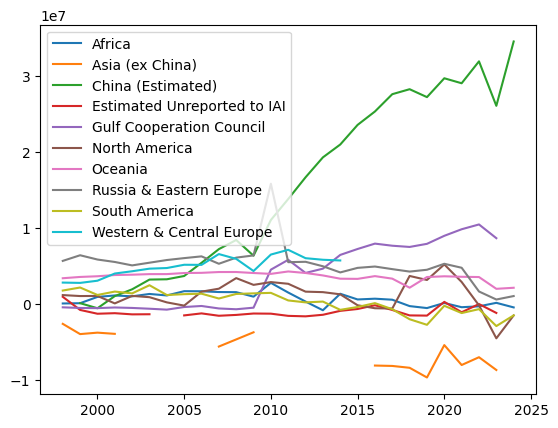

In [3]:
aluminium.sum_IMAGE_drivers_regions(IAI_TO_IMAGE_CLASSES)
aluminium.match_MAT_data_to_regions_year(match_external_regions=True)
aluminium.calculate_historic_other_fraction()
aluminium.historic_other_fraction_consumption.plot()

In [4]:
aluminium.historic_other_fraction_consumption

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


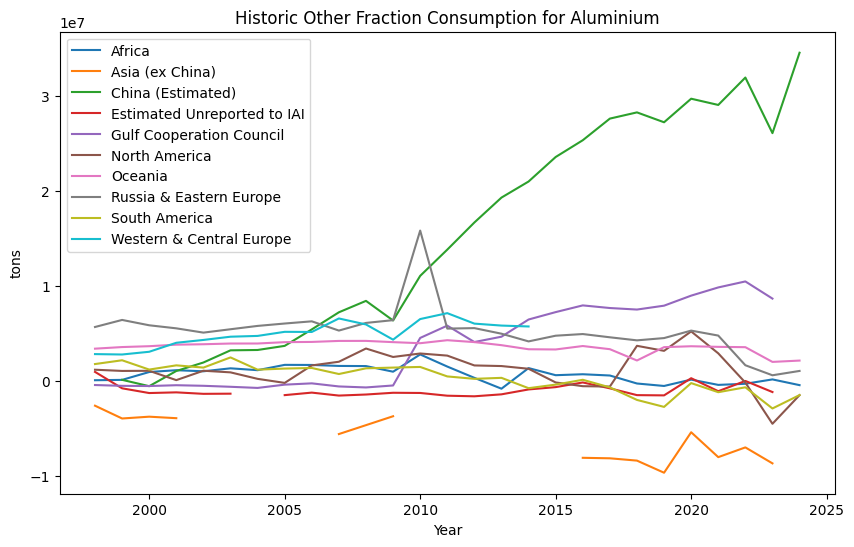

In [5]:
# Plot historic aother fraction app consumption

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(aluminium.historic_other_fraction_consumption, 
        label = aluminium.historic_other_fraction_consumption.columns)
ax.set_title('Historic Other Fraction Consumption for Aluminium')
plt.xlabel('Year')
plt.ylabel('tons')

plt.legend()

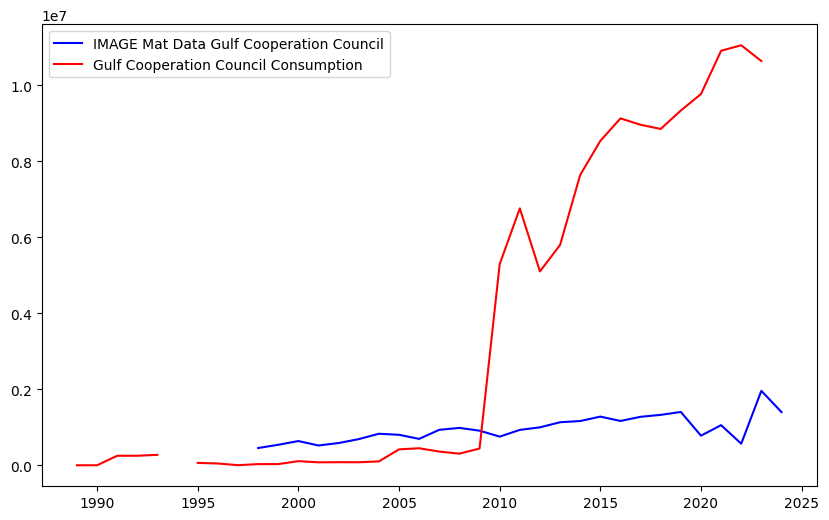

In [6]:
# Plot IMAGE Mat data and apparent cons data for region x

#
region_name = 'Gulf Cooperation Council'

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(aluminium.image_mat_material_regions.loc[:, region_name], 
                                                 label= f'IMAGE Mat Data {region_name}', color='blue')

ax.plot(aluminium.historic_consumption_data.loc[:, region_name], 
        label = f'{region_name} Consumption', color='red')

plt.legend()


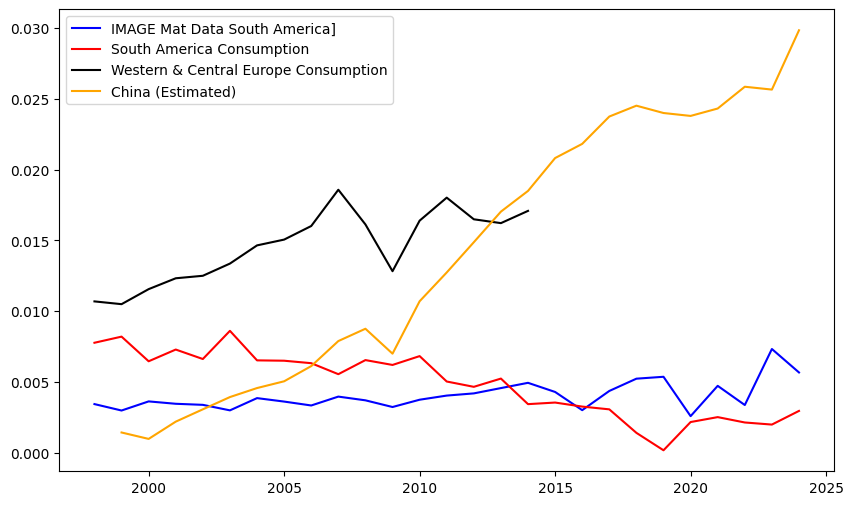

In [7]:
# Plot IMAGE Mat data and apparent cons per capita data for region x

#
region_name = 'South America'

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(aluminium.image_mat_material_regions.loc[:, region_name] / aluminium.pop_100.loc[1998:2024, region_name], 
                                                 label= f'IMAGE Mat Data {region_name}]', color='blue')

ax.plot(aluminium.historic_consumption_data.loc[:, region_name] / aluminium.pop_100.loc[1998:2024, region_name], 
        label = f'{region_name} Consumption', color='red')

ax.plot(aluminium.historic_consumption_data.loc[:, 'Western & Central Europe'] / aluminium.pop_100.loc[1998:2024, 'Western & Central Europe'], 
        label = 'Western & Central Europe Consumption', color='black')

ax.plot(aluminium.historic_consumption_data.loc[:, 'China (Estimated)'] / aluminium.pop_100.loc[1998:2024, 'China (Estimated)'], 
        label = 'China (Estimated)', color='orange')

# ax.plot(aluminium.historic_consumption_data.loc[:, 'Africa'] / aluminium.pop_100.loc[1998:2024, 'Africa'], 
#         label = 'Africa', color='green')

# ax.plot(aluminium.image_mat_material_regions.loc[:, 'Africa'] / aluminium.pop_100.loc[1998:2024, 'Africa'], 
#                                                  label='IMAGE Mat Data Africa', color='turquoise')

plt.legend()


In [8]:
# Deal with negative values in other fraction BEFORE recalculation of other fraction consumption

# 1) Africa: all negative: assumption that apparent MAT is 60% of total consumption (mean until 2017)
# Share of IAMGE MAT data to total consumption
share = (aluminium.image_mat_material_regions.loc[:2017]/aluminium.historic_consumption_data.loc[:2017]*100).mean()
share['Africa']

# starting at 2013 (when negative values start):
aluminium.image_mat_material_regions.loc[:, 'Africa'] = aluminium.historic_consumption_data.loc[:, 'Africa'] * share['Africa'] / 100

# 4) North America
# problem starts at 2015, so take share mean of IMAGE Mat data before that and apply it to 2015-2024
share_na = (aluminium.image_mat_material_regions.loc[:2015]/aluminium.historic_consumption_data.loc[:2015]*100).mean()
aluminium.image_mat_material_regions.loc[:, 'North America'] = aluminium.historic_consumption_data.loc[:, 'North America'] * share_na['North America'] / 100

# 6) South America: assume that share of Mat until 2010 is correct and that apparent consumption needs to be adjusted accordingly 
share_sa = (aluminium.image_mat_material_regions.loc[:2010, 'South America'] / aluminium.historic_consumption_data.loc[:2010, 'South America']).mean()
aluminium.historic_consumption_data.loc[:, 'South America'] = aluminium.image_mat_material_regions.loc[:, 'South America'] / share_sa

# Deal with negative values in other fraction AFTER recalculation of other fraction consumption
# redo calculation of historic other fraction consumption 
aluminium.calculate_historic_other_fraction()

# 2) rest of Asia: assume that IMAGE Mat is correct and is total per cap consumption 
# so will be projected on total not on diff
aluminium.historic_other_fraction_consumption.loc[:, 'Asia (ex China)'] = aluminium.historic_consumption_data.loc[:, 'Asia (ex China)']


# 3) Estimated Unreported to IAI: assume that IMAGE Mat is correct (these are mostlly IMAGE region 6 regions)
# Most are small island territories, overseas territories or constituent countries mainly linked to France
aluminium.historic_other_fraction_consumption.loc[:, 'Estimated Unreported to IAI'] = aluminium.historic_consumption_data.loc[:, 'Estimated Unreported to IAI']

# 5) Gulf Cooperation Council: remove negative values to nan, no problems in more recent years
aluminium.historic_other_fraction_consumption.loc[aluminium.historic_other_fraction_consumption.loc[:, 'Gulf Cooperation Council'] < 0, 'Gulf Cooperation Council'] = np.nan

# Finally check the whole dataframe for single negative values and make them NaN
aluminium.historic_other_fraction_consumption[aluminium.historic_other_fraction_consumption < 0] = np.nan

In [9]:
aluminium.historic_other_fraction_consumption

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1988,NaN,6.264801e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,NaN,5.223609e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990,NaN,3.435971e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991,NaN,6.191659e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992,NaN,7.972590e+05,NaN,4.689961e+06,NaN,NaN,NaN,NaN,NaN,NaN
1993,NaN,5.913259e+05,NaN,4.738436e+06,NaN,NaN,NaN,NaN,NaN,NaN
1994,NaN,6.325063e+05,NaN,3.989005e+06,NaN,NaN,NaN,NaN,NaN,NaN
1995,NaN,2.960242e+05,NaN,2.362097e+06,NaN,NaN,NaN,NaN,NaN,NaN
1996,NaN,3.865528e+05,NaN,2.216125e+06,NaN,NaN,NaN,NaN,NaN,NaN
1997,NaN,4.942532e+05,NaN,1.749081e+06,NaN,NaN,NaN,NaN,NaN,NaN


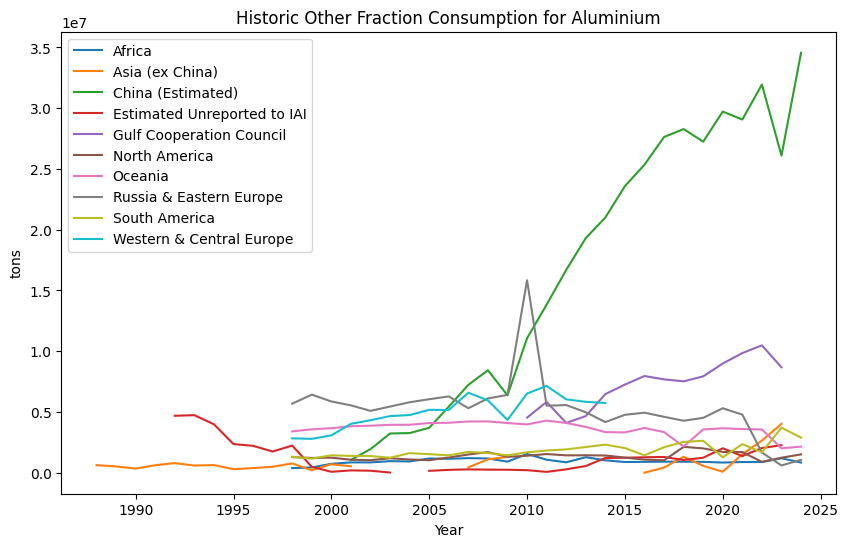

In [10]:
# Plot historic aother fraction app consumption

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(aluminium.historic_other_fraction_consumption, 
        label = aluminium.historic_other_fraction_consumption.columns)
ax.set_title('Historic Other Fraction Consumption for Aluminium')
plt.xlabel('Year')
plt.ylabel('tons')

plt.legend()

In [11]:
# Fit models
aluminium.calculate_regressors(aluminium.historic_other_fraction_consumption)
aluminium.fit_models(best_rmse_models={'all_together': 'logistic growth model',
                                       'china': 'gompertz model',
                                    'oceania': 'gompertz model'}) 

aluminium.region_model_match
aluminium.rmse_r2_groups

limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.


C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:281: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * np.exp(-c * X))
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y) #bounds

{'all_together':                               RMSE       R^2
 Model                                       
 log-log model             0.000065  0.270234
 semi-log model            0.000050  0.092283
 log-inverse model         0.000057  0.260674
 log-log-inverse model     0.000061  0.277328
 log-log-square model      0.000054  0.314079
 non-linear inverse model  0.000047       NaN
 gompertz model            0.000039       NaN
 logistic growth model     0.000039       NaN
 limited growth model      0.000044       NaN,
 'china':                                   RMSE       R^2
 Model                                           
 log-log model             6.510380e-06  0.831037
 semi-log model            3.051777e-06  0.918230
 log-inverse model         9.136235e-07  0.897762
 log-log-inverse model     2.934727e-06  0.913252
 log-log-square model      2.991807e-06  0.897653
 non-linear inverse model  5.904296e-07       NaN
 gompertz model            4.551086e-07       NaN
 logistic growth m

<Axes: >

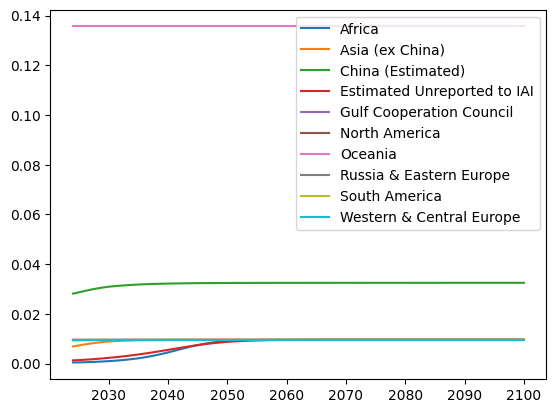

In [12]:

# Projections
aluminium.project_on_total(list(IAI_TO_IMAGE_CLASSES.keys()))



aluminium.projection_per_region.plot()

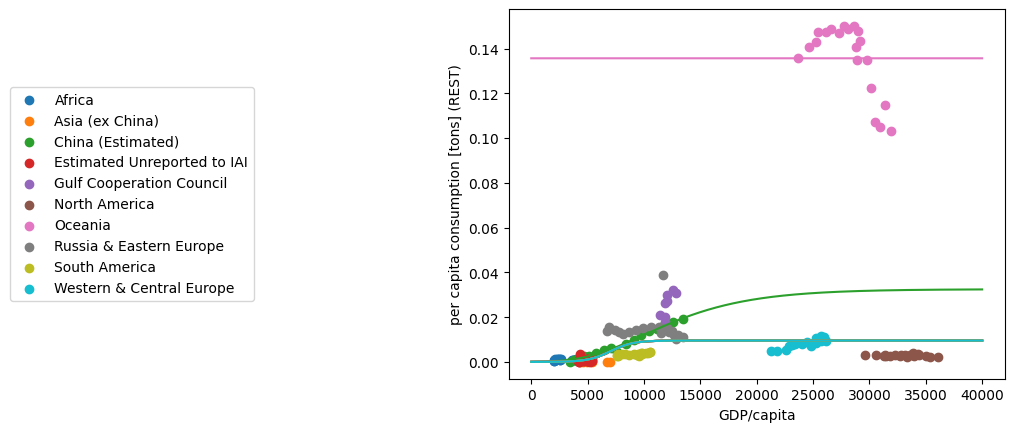

In [13]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', '#637939', '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in aluminium.cons_capita.columns:
    ax.scatter(aluminium.gdp_pc[region], 
               aluminium.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
    
    ax.plot(aluminium.region_model_match.get(region).predict(np.arange(1, 40001).reshape(-1, 1)),
            color = color_dict.get(region))

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")



ax.legend(loc = 'right', bbox_to_anchor=(-0.5, 0.5))

In [14]:
# # Rest of Asia and Estimated Unreported to IAI where fitted on total, 
# # so those values are not rest of but total values, therefore do not need to be added with MAT to get total

# # only add image mat values for the other regions to projection data

# aluminium.projection_per_region_total_min_mat = aluminium.projection_per_region_total.copy()
# aluminium.projection_per_region_total_min_mat.loc[2024:, ['Western & Central Europe', 'North America', 
#                                                 'Oceania', 'Africa', 'China (Estimated)',
#                                                 'Gulf Cooperation Council',
#                                                 'Russia & Eastern Europe', 'South America']] = (
#                                                   aluminium.image_mat_material_regions.loc[2024:, ['Western & Central Europe', 
#                                                             'North America',
#                                                             'Oceania', 'Africa', 'China (Estimated)',
#                                                             'Gulf Cooperation Council',
#                                                             'Russia & Eastern Europe', 'South America']].values + 
#                                                                 aluminium.projection_per_region.loc[:, ['Western & Central Europe', 
#                                                                                                         'North America',
#                                                                                                         'Oceania', 'Africa', 'China (Estimated)',
#                                                                                                         'Gulf Cooperation Council',
#                                                                                                         'Russia & Eastern Europe', 
#                                                                                                         'South America']].values
                                                                                                        # )

In [15]:
aluminium.projection_per_region_total

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2096,2.643782e+07,3.383233e+07,2.750284e+07,1.984525e+07,4.092901e+06,6.302938e+06,7.222976e+06,3.266535e+06,5.212658e+06,6.058003e+06
2097,2.648119e+07,3.369569e+07,2.722547e+07,1.987545e+07,4.088571e+06,6.300337e+06,7.211544e+06,3.252093e+06,5.190535e+06,6.040503e+06
2098,2.652456e+07,3.355905e+07,2.694809e+07,1.990566e+07,4.084241e+06,6.297736e+06,7.200113e+06,3.237651e+06,5.168412e+06,6.023002e+06
2099,2.656792e+07,3.342240e+07,2.667071e+07,1.993586e+07,4.079911e+06,6.295135e+06,7.188681e+06,3.223209e+06,5.146288e+06,6.005502e+06


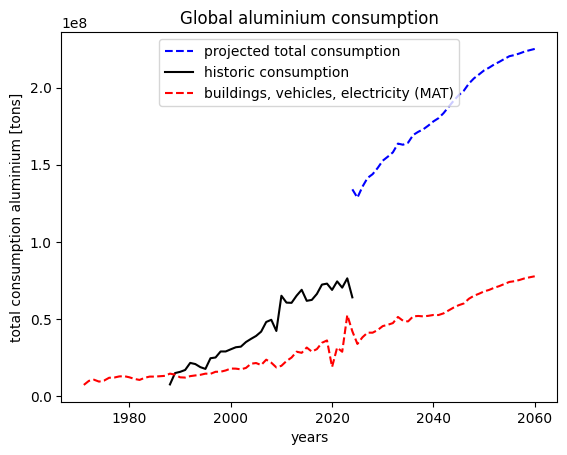

In [16]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(aluminium.projection_per_region_total.loc[2024:, ].sum(axis = 1) + aluminium.image_mat_data.loc[2024:, ].sum(axis = 1),
        linestyle = '--', color = 'blue', label = 'projected total consumption')

# ax.plot(aluminium.projection_per_region_total_min_mat.loc[2024:, ].sum(axis = 1), 
#         linestyle = '--', color = 'green', label = 'projected total consumption min mat')

ax.plot(aluminium.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(aluminium.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.set_ylabel("total consumption aluminium [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global aluminium consumption")
ax.legend(loc = 'upper center')